In [3]:
from google.colab import files
files.upload()  # upload kaggle.json (Kaggle → Account → API → Create New Token)

import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.config/kaggle/')
os.system('chmod 600 /root/.config/kaggle/kaggle.json')
os.system('pip install kaggle -q')
os.system('kaggle datasets download -d sigfest/database-for-emotion-recognition-system-gameemo')
os.system('unzip -q database-for-emotion-recognition-system-gameemo.zip -d gameemo')
print('Dataset downloaded!')

# Check folder structure
for root, dirs, files_list in os.walk('gameemo'):
    level = root.replace('gameemo', '').count(os.sep)
    if level < 3:
        print(' ' * 2 * level + os.path.basename(root) + '/')
        for f in files_list[:3]:
            print(' ' * 2 * (level+1) + f)

Saving kaggle.json to kaggle.json
Dataset downloaded!
gameemo/
  GAMEEMO/
    (S27)/
    (S14)/
    (S10)/
    (S28)/
    (S12)/
    Gameplays/
    (S15)/
    (S09)/
    (S22)/
    (S21)/
    (S16)/
    (S26)/
    (S03)/
    (S13)/
    (S19)/
    (S07)/
    (S02)/
    (S25)/
    (S23)/
    (S05)/
    (S18)/
    (S20)/
    (S17)/
    (S06)/
    (S01)/
    (S08)/
    (S04)/
    (S24)/
    (S11)/


In [4]:
import numpy as np
import pandas as pd
from scipy.signal import welch
from scipy.stats import pearsonr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('All imports done | PyTorch:', torch.__version__)
print('GPU available:', torch.cuda.is_available())

All imports done | PyTorch: 2.10.0+cpu
GPU available: False


In [8]:
CHANNELS      = ['AF3','AF4','F3','F4','F7','F8','FC5','FC6','O1','O2','P7','P8','T7','T8']
GAME_LABEL    = {'G1': 0, 'G2': 1, 'G3': 2, 'G4': 3}
EMOTION_NAMES = {0: 'Boring', 1: 'Calm', 2: 'Horror', 3: 'Funny'}
SAMPLING_RATE = 128   # Hz — EMOTIV EPOC+ default
WINDOW_SIZE   = 128   # 1 second = 128 samples
STEP_SIZE     = 64    # 50% overlap
import re

In [9]:
def find_csv_files(base_path):
    csv_files = []
    for root, dirs, files_list in os.walk(base_path):
        for f in files_list:
            if 'AllChannels' in f and f.endswith('.csv'):
                # Only take preprocessed, not raw
                # Also skip duplicate nested folders (e.g. S26 inside S28)
                if 'Preprocessed' not in root:
                    continue
                # Skip if subject folder is nested inside another subject's folder
                # e.g. (S28)/(S26) — count subject folder patterns in path
                subject_folders = re.findall(r'\(S\d+\)', root)
                if len(subject_folders) > 1:
                    continue
                match = re.match(r'S(\d+)(G\d+)', f.replace('AllChannels.csv', ''))
                if match:
                    subject = 'S' + match.group(1).zfill(2)
                    game    = match.group(2)
                    label   = GAME_LABEL.get(game, -1)
                    if label != -1:
                        csv_files.append({
                            'path': os.path.join(root, f),
                            'subject': subject,
                            'game': game,
                            'label': label
                        })
    return sorted(csv_files, key=lambda x: (x['subject'], x['game']))

csv_files = find_csv_files('gameemo')
print(f'Found {len(csv_files)} CSV files')  # should be exactly 112

Found 112 CSV files


In [10]:

csv_files = find_csv_files('gameemo')
print(f'Found {len(csv_files)} CSV files')
for f in csv_files[:4]:
    print(f"  {f['subject']} {f['game']} → {EMOTION_NAMES[f['label']]} | {f['path']}")

Found 112 CSV files
  S01 G1 → Boring | gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G1AllChannels.csv
  S01 G2 → Calm | gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G2AllChannels.csv
  S01 G3 → Horror | gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G3AllChannels.csv
  S01 G4 → Funny | gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G4AllChannels.csv


In [11]:
 # EEG frequency bands — each captures a different brain state
BANDS = {
    'delta': (0.5, 4),   # deep sleep / baseline
    'theta': (4,   8),   # drowsiness
    'alpha': (8,  13),   # relaxation
    'beta':  (13, 30),   # active thinking
    'gamma': (30, 50)    # high arousal
}

def compute_band_power(signal, fs=128):
    """
    Welch's method: robust PSD estimation for short signals.
    Returns array of shape (5,) — one power value per band.
    """
    freqs, psd = welch(signal, fs=fs, nperseg=min(len(signal), fs))
    return np.array([
        np.trapz(psd[(freqs >= lo) & (freqs <= hi)],
                 freqs[(freqs >= lo) & (freqs <= hi)])
        for _, (lo, hi) in BANDS.items()
    ])

def extract_node_features(window):
    """
    window: (128, 14)
    Returns node features: (14, 5) — each electrode gets 5 band powers
    """
    return np.array([compute_band_power(window[:, ch]) for ch in range(window.shape[1])])

# Test
dummy = np.random.randn(128, 14)
print('Node features shape:', extract_node_features(dummy).shape)  # (14, 5)

Node features shape: (14, 5)


In [12]:
CORR_THRESHOLD = 0.5  # connect two electrodes if |correlation| > this

def build_adjacency(window, threshold=CORR_THRESHOLD):
    """
    Functional connectivity graph.
    A[i][j] = 1 if Pearson correlation(channel_i, channel_j) > threshold.
    window: (128, 14) → returns adj: (14, 14)
    """
    n = window.shape[1]
    adj = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                corr, _ = pearsonr(window[:, i], window[:, j])
                if abs(corr) > threshold:
                    adj[i][j] = 1.0
    adj += np.eye(n)   # self-loops
    return adj

def normalize_adjacency(adj):
    """
    GCN normalization from Kipf & Welling 2017:
        A_hat = D^(-1/2) * A * D^(-1/2)
    Prevents high-degree nodes from dominating aggregation.
    """
    degree    = adj.sum(axis=1)
    d_inv_sq  = np.where(degree > 0, degree ** -0.5, 0)
    D_inv_sq  = np.diag(d_inv_sq)
    return D_inv_sq @ adj @ D_inv_sq

# Test
dummy = np.random.randn(128, 14)
adj   = build_adjacency(dummy)
print('Adjacency shape:', adj.shape)          # (14, 14)
print('Avg edges per node:', adj.sum() / 14)

Adjacency shape: (14, 14)
Avg edges per node: 1.0


In [15]:
def process_file(file_info):
    df    = pd.read_csv(file_info['path'])
    cols  = [c for c in CHANNELS if c in df.columns]
    data  = df[cols].values          # (total_rows, 14)
    label = file_info['label']
    samples = []
    for start in range(0, len(data) - WINDOW_SIZE, STEP_SIZE):
        window = data[start:start + WINDOW_SIZE]   # (128, 14)
        feats  = extract_node_features(window)     # (14, 5)
        adj    = normalize_adjacency(build_adjacency(window))  # (14, 14)
        samples.append((feats, adj, label))
    return samples

print('Processing all 112 CSV files..')
all_samples = []
for i, fi in enumerate(csv_files):
    s = process_file(fi)
    all_samples.extend(s)
    if (i+1) % 10 == 0 or i == 0:
        print(f'  [{i+1}/{len(csv_files)}] {fi["subject"]} {fi["game"]} → {len(s)} windows')

print(f'\nTotal samples: {len(all_samples)}')
from collections import Counter
for label, count in sorted(Counter(s[2] for s in all_samples).items()):
    print(f'  {EMOTION_NAMES[label]}: {count}')

Processing all 112 CSV files..
  [1/112] S01 G1 → 596 windows
  [10/112] S03 G2 → 596 windows
  [20/112] S05 G4 → 596 windows
  [30/112] S08 G2 → 596 windows
  [40/112] S10 G4 → 596 windows
  [50/112] S13 G2 → 596 windows
  [60/112] S15 G4 → 596 windows
  [70/112] S18 G2 → 596 windows
  [80/112] S20 G4 → 596 windows
  [90/112] S23 G2 → 596 windows
  [100/112] S25 G4 → 596 windows
  [110/112] S28 G2 → 596 windows

Total samples: 66752
  Boring: 16688
  Calm: 16688
  Horror: 16688
  Funny: 16688


In [16]:
X_feat = torch.tensor(np.array([s[0] for s in all_samples]), dtype=torch.float32)
X_adj  = torch.tensor(np.array([s[1] for s in all_samples]), dtype=torch.float32)
y      = torch.tensor(np.array([s[2] for s in all_samples]), dtype=torch.long)

print('Features:', X_feat.shape)   # (N, 14, 5)
print('Adjacency:', X_adj.shape)   # (N, 14, 14)
print('Labels:', y.shape)          # (N,)

indices = np.arange(len(all_samples))
train_idx, test_idx = train_test_split(indices, test_size=0.2,
                                        random_state=42, stratify=y.numpy())
X_feat_train, X_feat_test = X_feat[train_idx], X_feat[test_idx]
X_adj_train,  X_adj_test  = X_adj[train_idx],  X_adj[test_idx]
y_train,       y_test      = y[train_idx],       y[test_idx]
print(f'Train: {len(train_idx)} | Test: {len(test_idx)}')

Features: torch.Size([66752, 14, 5])
Adjacency: torch.Size([66752, 14, 14])
Labels: torch.Size([66752])
Train: 53401 | Test: 13351


In [17]:
# Normalize node features (zero mean, unit variance per feature)
mean = X_feat_train.mean(dim=0, keepdim=True)
std  = X_feat_train.std(dim=0, keepdim=True) + 1e-8

X_feat_train = (X_feat_train - mean) / std
X_feat_test  = (X_feat_test  - mean) / std  # use train mean/std on test

In [18]:
class GCNLayer(nn.Module):
    """
    Single GCN layer:
        H_out = ReLU( A_norm @ H_in @ W )
    A_norm aggregates neighbor features,
    W transforms them — both learned end-to-end.
    """
    def __init__(self, in_f, out_f):
        super().__init__()
        self.W = nn.Linear(in_f, out_f, bias=False)

    def forward(self, H, A):
        # H: (batch, 14, in_f) | A: (batch, 14, 14)
        return F.relu(self.W(torch.bmm(A, H)))

class EmotionGCN(nn.Module):
    """
    2-layer GCN → mean pooling → MLP → 4-class emotion output
    Input:  (batch, 14, 5) node features + (batch, 14, 14) adjacency
    Output: (batch, 4) logits
    """
    def __init__(self):
        super().__init__()
        self.gcn1  = GCNLayer(5, 32)
        self.gcn2  = GCNLayer(32, 64)
        self.drop  = nn.Dropout(0.3)
        self.clf   = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32, 4)
        )

    def forward(self, H, A):
        H = self.drop(self.gcn1(H, A))   # (batch, 14, 32)
        H = self.gcn2(H, A)              # (batch, 14, 64)
        H = H.mean(dim=1)                # mean pool over 14 nodes → (batch, 64)
        return self.clf(H)               # (batch, 4)

model = EmotionGCN()
print(model)
print('Parameters:', sum(p.numel() for p in model.parameters()))

EmotionGCN(
  (gcn1): GCNLayer(
    (W): Linear(in_features=5, out_features=32, bias=False)
  )
  (gcn2): GCNLayer(
    (W): Linear(in_features=32, out_features=64, bias=False)
  )
  (drop): Dropout(p=0.3, inplace=False)
  (clf): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=4, bias=True)
  )
)
Parameters: 4420


In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

model     = EmotionGCN().to(device)
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

X_feat_train = X_feat_train.to(device); X_adj_train = X_adj_train.to(device); y_train = y_train.to(device)
X_feat_test  = X_feat_test.to(device);  X_adj_test  = X_adj_test.to(device);  y_test  = y_test.to(device)

BATCH_SIZE, EPOCHS = 32, 200
train_losses, test_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    perm, loss_sum = torch.randperm(len(y_train)), 0
    for i in range(0, len(y_train), BATCH_SIZE):
        idx   = perm[i:i+BATCH_SIZE]
        optimizer.zero_grad()
        loss  = criterion(model(X_feat_train[idx], X_adj_train[idx]), y_train[idx])
        loss.backward(); optimizer.step()
        loss_sum += loss.item()
    avg_loss = loss_sum / (len(y_train) // BATCH_SIZE)
    train_losses.append(avg_loss)

    model.eval()
    with torch.no_grad():
        preds = model(X_feat_test, X_adj_test).argmax(dim=1)
        acc   = (preds == y_test).float().mean().item()
    test_accs.append(acc)

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Test Acc: {acc*100:.2f}%')

print('Training done!')

Device: cpu
Epoch  5/200 | Loss: 1.3159 | Test Acc: 34.86%
Epoch 10/200 | Loss: 1.3011 | Test Acc: 37.39%
Epoch 15/200 | Loss: 1.2902 | Test Acc: 37.86%
Epoch 20/200 | Loss: 1.2814 | Test Acc: 39.28%
Epoch 25/200 | Loss: 1.2774 | Test Acc: 38.93%
Epoch 30/200 | Loss: 1.2715 | Test Acc: 39.61%
Epoch 35/200 | Loss: 1.2678 | Test Acc: 38.77%
Epoch 40/200 | Loss: 1.2648 | Test Acc: 40.18%
Epoch 45/200 | Loss: 1.2623 | Test Acc: 39.37%
Epoch 50/200 | Loss: 1.2609 | Test Acc: 40.12%
Epoch 55/200 | Loss: 1.2589 | Test Acc: 39.73%
Epoch 60/200 | Loss: 1.2556 | Test Acc: 40.17%
Epoch 65/200 | Loss: 1.2569 | Test Acc: 40.69%
Epoch 70/200 | Loss: 1.2534 | Test Acc: 40.06%
Epoch 75/200 | Loss: 1.2536 | Test Acc: 39.96%
Epoch 80/200 | Loss: 1.2516 | Test Acc: 40.90%
Epoch 85/200 | Loss: 1.2516 | Test Acc: 39.98%
Epoch 90/200 | Loss: 1.2518 | Test Acc: 40.72%
Epoch 95/200 | Loss: 1.2494 | Test Acc: 40.33%
Epoch 100/200 | Loss: 1.2487 | Test Acc: 40.91%
Epoch 105/200 | Loss: 1.2489 | Test Acc: 40.39%

              precision    recall  f1-score   support

      Boring       0.40      0.48      0.44      3338
        Calm       0.42      0.33      0.37      3337
      Horror       0.38      0.40      0.39      3338
       Funny       0.44      0.42      0.43      3338

    accuracy                           0.41     13351
   macro avg       0.41      0.41      0.41     13351
weighted avg       0.41      0.41      0.41     13351

Final Accuracy: 40.77%


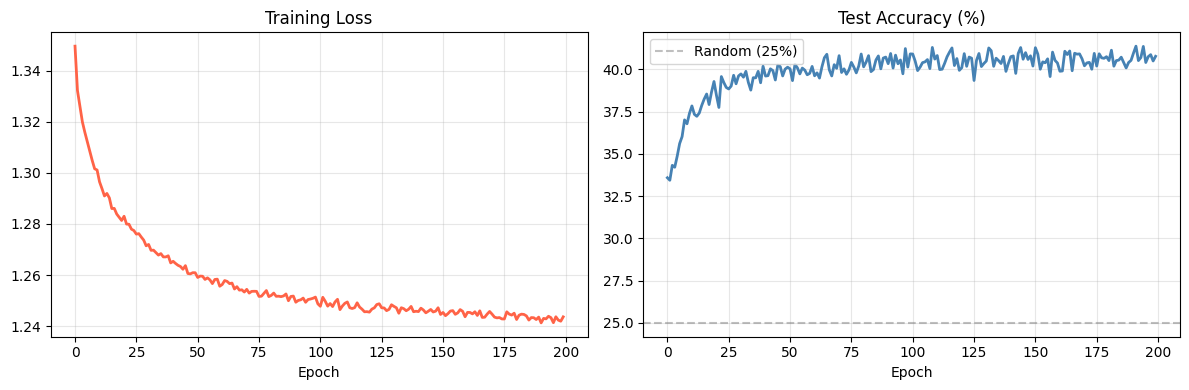

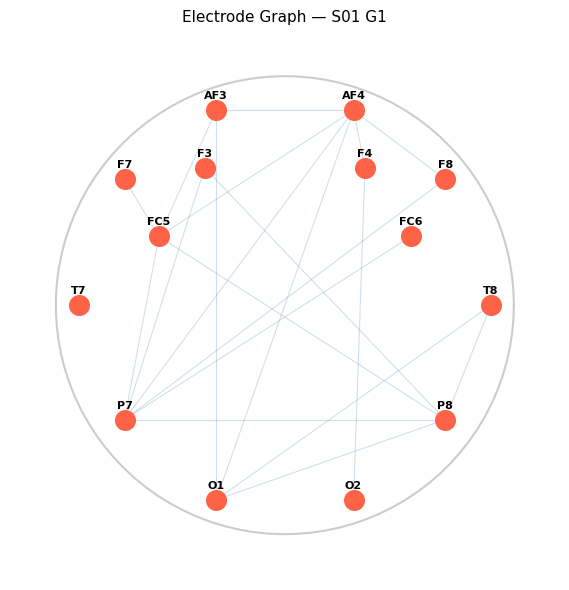

In [21]:
model.eval()
with torch.no_grad():
    preds = model(X_feat_test, X_adj_test).argmax(dim=1).cpu().numpy()
true = y_test.cpu().numpy()

print(classification_report(true, preds, target_names=list(EMOTION_NAMES.values())))
print(f'Final Accuracy: {accuracy_score(true, preds)*100:.2f}%')

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, color='tomato', lw=2); ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch'); ax1.grid(True, alpha=0.3)
ax2.plot([a*100 for a in test_accs], color='steelblue', lw=2)
ax2.axhline(25, color='gray', ls='--', alpha=0.5, label='Random (25%)')
ax2.set_title('Test Accuracy (%)'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('training_curves.png', dpi=150); plt.show()

# Electrode graph visualization
ELECTRODE_POS = {
    'AF3':(-0.3,0.85),'AF4':(0.3,0.85),
    'F7':(-0.7,0.55),'F3':(-0.35,0.6),'F4':(0.35,0.6),'F8':(0.7,0.55),
    'FC5':(-0.55,0.3),'FC6':(0.55,0.3),
    'T7':(-0.9,0),'T8':(0.9,0),
    'P7':(-0.7,-0.5),'P8':(0.7,-0.5),
    'O1':(-0.3,-0.85),'O2':(0.3,-0.85)
}
sample = pd.read_csv(csv_files[0]['path'])[CHANNELS].values[:128]
adj_vis = build_adjacency(sample)

fig, ax = plt.subplots(figsize=(6,6))
for i, ci in enumerate(CHANNELS):
    for j, cj in enumerate(CHANNELS):
        if i < j and adj_vis[i][j]:
            ax.plot([ELECTRODE_POS[ci][0], ELECTRODE_POS[cj][0]],
                    [ELECTRODE_POS[ci][1], ELECTRODE_POS[cj][1]], 'steelblue', alpha=0.25, lw=0.8)
for ch in CHANNELS:
    x, y_p = ELECTRODE_POS[ch]
    ax.scatter(x, y_p, s=200, c='tomato', zorder=5)
    ax.annotate(ch, (x, y_p), xytext=(0,8), textcoords='offset points',
                ha='center', fontsize=8, fontweight='bold')
t = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(t), np.sin(t), 'k-', lw=1.5, alpha=0.2)
ax.set_xlim(-1.2,1.2); ax.set_ylim(-1.2,1.2); ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Electrode Graph — S01 G1', fontsize=11)
plt.tight_layout();
plt.savefig('electrode_graph.png', dpi=150); plt.show()